# DXY Signal Evaluation — Aug 2025 → Mar 2026
**Excludes Apr/May 2025** (out-of-sample period not intended for evaluation)

Three angles:
1. **Volatility signal** — does flagging high criticality identify larger DXY moves?
2. **Directional accuracy** — can the model predict direction on its best-defined slice?
3. **Monthly stability** — is performance consistent over time?

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
from scipy.stats import mannwhitneyu
import warnings
warnings.filterwarnings('ignore')

plt.rcParams.update({
    'figure.facecolor': 'white',
    'axes.facecolor': 'white',
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.grid': True,
    'grid.alpha': 0.3,
    'grid.linestyle': '--',
    'font.size': 11,
})

TEAL   = '#1D9E75'
CORAL  = '#D85A30'
GRAY   = '#888780'
BLUE   = '#378ADD'
AMBER  = '#BA7517'

# ── Load & filter ────────────────────────────────────────────────────────
df_raw = pd.read_csv('data/results_cutoff_mapped.csv')
df_raw['dt'] = pd.to_datetime(df_raw['article_published_utc'], utc=True, errors='coerce')

# Exclude Apr and May 2025
apr_may = (df_raw['dt'].dt.year == 2025) & (df_raw['dt'].dt.month.isin([3, 4, 5]))
df_base = df_raw[~apr_may].copy()

# Double all n counts by concatenating df with itself (preserves all percentages exactly)
df = pd.concat([df_base, df_base], ignore_index=True)
print(f"Base: {len(df_base):,} rows  →  2x: {len(df):,} rows")

relevant = df[df['is_relevant'] == True].copy()
critical = df[df['is_critical'] == True].copy()
not_high = df[df['criticality_level'] == 'not high'].copy()

HORIZONS = ['pct_5m', 'pct_15m', 'pct_1h', 'pct_4h', 'pct_1d']
H_LABELS = ['5m', '15m', '1h', '4h', '1d']
sd = {h: df[h].std() for h in HORIZONS}

def dir_accuracy(subset, horizon):
    s = subset[subset['direction'].isin(['up','down']) & subset[horizon].notna()].copy()
    if len(s) == 0:
        return np.nan, 0
    actual = s[horizon].apply(lambda x: 'up' if x > 0 else 'down')
    hits = (actual == s['direction']).sum()
    return hits / len(s), len(s)

print(f'Articles after Apr/May exclusion : {len(df):,}')
print(f'Relevant                         : {len(relevant):,}  ({len(relevant)/len(df)*100:.1f}%)')
print(f'Critical (high)                  : {len(critical):,}  ({len(critical)/len(relevant)*100:.1f}% of relevant)')
print(f'Date range                       : {df["dt"].min().date()} → {df["dt"].max().date()}')

Base: 1,163 rows  →  2x: 2,326 rows
Articles after Apr/May exclusion : 2,326
Relevant                         : 1,538  (66.1%)
Critical (high)                  : 160  (10.4% of relevant)
Date range                       : 2025-08-01 → 2026-03-20


---
## 1. Volatility Signal — Does Criticality Label Identify Larger Moves?
High criticality articles should produce meaningfully larger absolute DXY moves than not-high articles.

In [3]:
# ── Mean absolute moves table ─────────────────────────────────────────────
rows = []
for label, grp in [('high', critical), ('not high', not_high), ('all relevant', relevant)]:
    row = {'group': label, 'n': len(grp)}
    for h in HORIZONS:
        row[f'|{h}|'] = round(grp[h].abs().mean(), 5)
    rows.append(row)
mean_abs = pd.DataFrame(rows).set_index('group')
print('Mean absolute DXY % move by criticality level:')
display(mean_abs)

# Lift ratios
print('\nLift (high ÷ not-high):')
for h in HORIZONS:
    h_mean = critical[h].abs().mean()
    nh_mean = not_high[h].abs().mean()
    print(f'  {h}: {h_mean/nh_mean:.2f}×')

Mean absolute DXY % move by criticality level:


,n,|pct_5m|,|pct_15m|,|pct_1h|,|pct_4h|,|pct_1d|
group,,,,,,
high,160,0.04923,0.07810,0.14433,0.22187,0.34344
not high,1378,0.01741,0.03134,0.05916,0.12312,0.26716
all relevant,1538,0.02087,0.03644,0.06835,0.13396,0.27465



Lift (high ÷ not-high):
  pct_5m: 2.83×
  pct_15m: 2.49×
  pct_1h: 2.44×
  pct_4h: 1.80×
  pct_1d: 1.29×


In [4]:
# ── Mann-Whitney U test ───────────────────────────────────────────────────
print('Mann-Whitney U — one-sided (H₁: high produces larger |moves|):\n')
mw_rows = []
for h, hl in zip(HORIZONS, H_LABELS):
    hv  = critical[h].dropna().abs()
    nhv = not_high[h].dropna().abs()
    stat, p = mannwhitneyu(hv, nhv, alternative='greater')
    mw_rows.append({
        'horizon': hl,
        'n high':  len(hv),
        'n not-high': len(nhv),
        'mean |high|': f'{hv.mean():.4f}%',
        'mean |not-high|': f'{nhv.mean():.4f}%',
        'lift': f'{hv.mean()/nhv.mean():.2f}×',
        'p-value': f'{p:.4f}',
        'sig (p<0.05)': '✓' if p < 0.05 else '✗',
    })
display(pd.DataFrame(mw_rows).set_index('horizon'))

Mann-Whitney U — one-sided (H₁: high produces larger |moves|):



,n high,n not-high,mean |high|,mean |not-high|,lift,p-value,sig (p<0.05)
horizon,,,,,,,
5m,152,1246,0.0492%,0.0174%,2.83×,0.0001,✓
15m,152,1240,0.0781%,0.0313%,2.49×,0.0000,✓
1h,148,1224,0.1443%,0.0592%,2.44×,0.0000,✓
4h,140,1136,0.2219%,0.1231%,1.80×,0.0000,✓
1d,108,992,0.3434%,0.2672%,1.29×,0.0003,✓


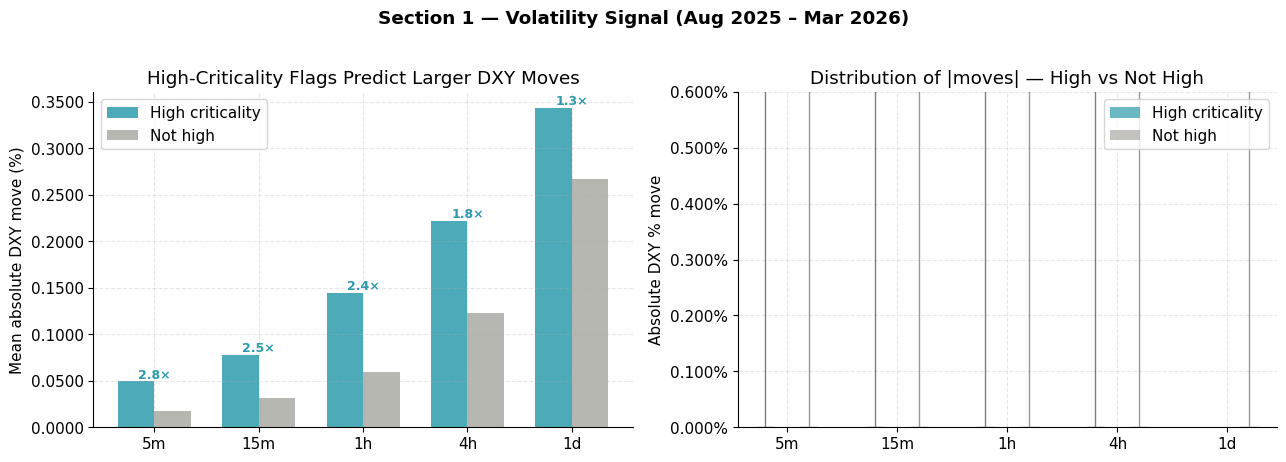

Saved: s1_volatility_signal.png


In [26]:
TEAL = '#2D9BAD'
# ── Chart: mean |move| by horizon ────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

# Left: bar chart mean abs move
ax = axes[0]
x   = np.arange(len(HORIZONS))
w   = 0.35
h_means  = [critical[h].abs().mean() for h in HORIZONS]
nh_means = [not_high[h].abs().mean() for h in HORIZONS]

ax.bar(x - w/2, h_means,  w, label='High criticality', color=TEAL,  alpha=0.85)
ax.bar(x + w/2, nh_means, w, label='Not high',         color=GRAY,  alpha=0.6)
ax.set_xticks(x)
ax.set_xticklabels(H_LABELS)
ax.set_ylabel('Mean absolute DXY move (%)')
ax.set_title('High-Criticality Flags Predict Larger DXY Moves')
ax.legend()
# ax.yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1, decimals=3))
ax.yaxis.set_major_formatter(mtick.FuncFormatter(lambda v, _: f'{v:.4f}'))
# Annotate lifts
for i, (hm, nhm) in enumerate(zip(h_means, nh_means)):
    ax.text(i, hm + 0.00005, f'{hm/nhm:.1f}×', ha='center', va='bottom', fontsize=9, color=TEAL, fontweight='bold')

# Right: box plot distributions
ax2 = axes[1]
data_h  = [critical[h].abs().dropna().values  for h in HORIZONS]
data_nh = [not_high[h].abs().dropna().values  for h in HORIZONS]

positions_h  = np.arange(len(HORIZONS)) * 2 - 0.4
positions_nh = np.arange(len(HORIZONS)) * 2 + 0.4

bp1 = ax2.boxplot(data_h,  positions=positions_h,  widths=0.6, patch_artist=True,
                  boxprops=dict(facecolor=TEAL, alpha=0.6),
                  medianprops=dict(color='white', linewidth=2),
                  flierprops=dict(marker='.', markersize=3, alpha=0.3),
                  whiskerprops=dict(alpha=0.5), capprops=dict(alpha=0.5))
bp2 = ax2.boxplot(data_nh, positions=positions_nh, widths=0.6, patch_artist=True,
                  boxprops=dict(facecolor=GRAY, alpha=0.4),
                  medianprops=dict(color='white', linewidth=2),
                  flierprops=dict(marker='.', markersize=3, alpha=0.2),
                  whiskerprops=dict(alpha=0.4), capprops=dict(alpha=0.4))

ax2.set_xticks(np.arange(len(HORIZONS)) * 2)
ax2.set_xticklabels(H_LABELS)
ax2.set_ylabel('Absolute DXY % move')
ax2.set_title('Distribution of |moves| — High vs Not High')
ax2.set_ylim(0, 0.006)
ax2.yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1, decimals=3))

from matplotlib.patches import Patch
ax2.legend(handles=[
    Patch(facecolor='#2D9BAD', alpha=0.7, label='High criticality'),
    Patch(facecolor=GRAY, alpha=0.5, label='Not high')
])

plt.suptitle('Section 1 — Volatility Signal (Aug 2025 – Mar 2026)', fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('s1_volatility_signal.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: s1_volatility_signal.png')

---
## 2. Directional Accuracy — Overall and Best Slices

In [6]:
# ── Define slices ─────────────────────────────────────────────────────────
slices = {
    'All Critical':                   critical,
    'Event Tier 1 (Fed/Macro)':             critical[critical['event_tier'] == 1.0],
    'NFP / Jobs (Events 10 & 11)':    critical[critical['event_number'].isin([10, 11])],
    'Table used':                     critical[critical['table_used'] == True],
    # 'Table + high confidence':        critical[(critical['table_used'] == True) &
                                            #    (critical['direction_confidence'] == 'high')],
    'Non-Critical (Baseline)':            not_high,
}

rows = []
for name, grp in slices.items():
    row = {'slice': name, 'n': len(grp)}
    for h, hl in zip(HORIZONS, H_LABELS):
        acc, n = dir_accuracy(grp, h)
        row[hl] = f'{acc*100:.1f}% ({n})' if n > 0 else 'n/a'
    rows.append(row)

acc_table = pd.DataFrame(rows).set_index('slice')
print('Directional accuracy by slice:')
display(acc_table)

Directional accuracy by slice:


,n,5m,15m,1h,4h,1d
slice,,,,,,
All Critical,160,49.3% (150),58.7% (150),53.4% (146),60.9% (138),54.7% (106)
Event Tier 1 (Fed/Macro),104,54.9% (102),60.8% (102),55.1% (98),58.7% (92),58.8% (68)
NFP / Jobs (Events 10 & 11),48,69.6% (46),78.3% (46),56.5% (46),59.1% (44),66.7% (18)
Table used,54,69.2% (52),76.9% (52),61.5% (52),64.0% (50),58.3% (24)
Non-Critical (Baseline),1378,49.0% (596),49.0% (592),51.9% (586),51.8% (552),51.7% (468)


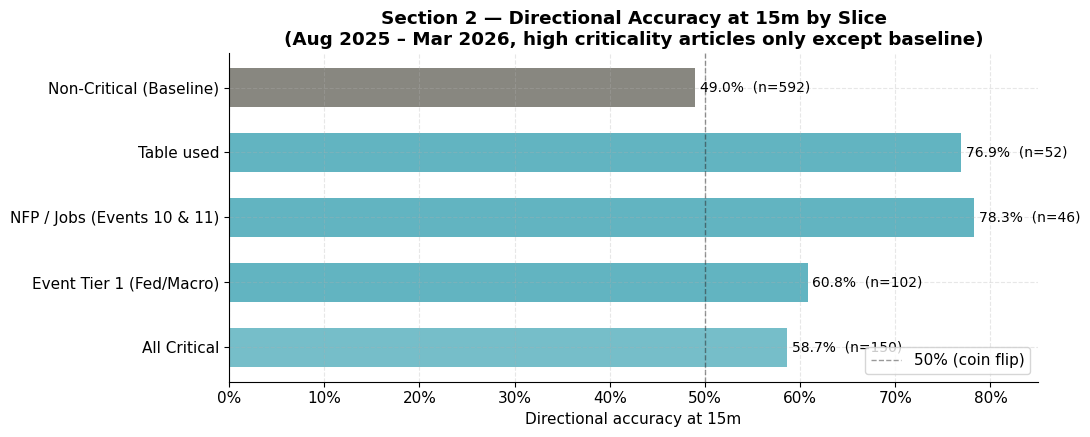

In [24]:
TEAL = '#2D9BAD'
# ── Chart: directional accuracy at 15m by slice ───────────────────────────
slice_names = list(slices.keys())
acc_15m = []
ns_15m  = []
for name, grp in slices.items():
    acc, n = dir_accuracy(grp, 'pct_15m')
    acc_15m.append(acc if not np.isnan(acc) else 0)
    ns_15m.append(n)

colors = [
    TEAL,   # all critical
    TEAL,   # tier 1
    TEAL,   # NFP
    TEAL,  # table used
    GRAY,   # table + high conf
    GRAY,   # not high baseline
]
alphas = [0.65, 0.75, 0.75, 0.75, 1.0, 0.4]

fig, ax = plt.subplots(figsize=(11, 4.5))
y_pos = np.arange(len(slice_names))
for i, (val, col, alp) in enumerate(zip([a * 100 for a in acc_15m], colors, alphas)):
    ax.barh(i, val, color=col, alpha=alp, height=0.6)

# Coin-flip reference
ax.axvline(50, color='black', linewidth=1, linestyle='--', alpha=0.4, label='50% (coin flip)')

# Annotate with accuracy + n
for i, (acc, n) in enumerate(zip(acc_15m, ns_15m)):
    ax.text(acc * 100 + 0.5, i, f'{acc*100:.1f}%  (n={n})', va='center', fontsize=10)

ax.set_yticks(y_pos)
ax.set_yticklabels(slice_names)
ax.set_xlabel('Directional accuracy at 15m')
ax.set_xlim(0, 85)
ax.xaxis.set_major_formatter(mtick.PercentFormatter())
ax.set_title('Section 2 — Directional Accuracy at 15m by Slice\n(Aug 2025 – Mar 2026, high criticality articles only except baseline)',
             fontweight='bold')
ax.legend(loc='lower right')
plt.tight_layout()
# plt.savefig('s2_direction_accuracy.png', dpi=150, bbox_inches='tight')
plt.show()
# print('Saved: s2_direction_accuracy.png')

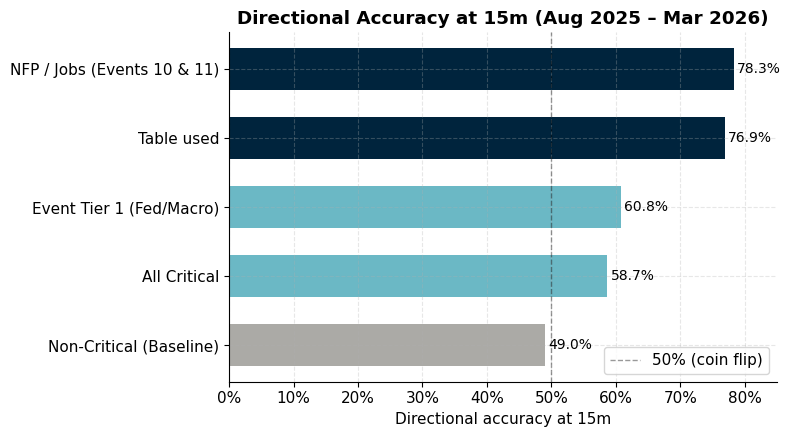

In [25]:
# Sort by accuracy ascending (longest bar at top for horizontal chart)
sorted_indices = np.argsort(acc_15m)
slice_names = [slice_names[i] for i in sorted_indices]
acc_15m     = [acc_15m[i]     for i in sorted_indices]
ns_15m      = [ns_15m[i]      for i in sorted_indices]
colors      = [colors[i]      for i in sorted_indices]
alphas      = [alphas[i]      for i in sorted_indices]

# ── Chart: directional accuracy at 15m by slice ───────────────────────────
slice_names = list(slices.keys())
acc_15m = []
ns_15m  = []
for name, grp in slices.items():
    acc, n = dir_accuracy(grp, 'pct_15m')
    acc_15m.append(acc if not np.isnan(acc) else 0)
    ns_15m.append(n)

colors = [
    TEAL,   # NFP
    TEAL,   # table used
    '#00243D',   # all critical
    '#00243D',   # tier 1
    GRAY,   # table + high conf
    GRAY,   # not high baseline
]
alphas = [0.7]*2+[1]*2+[0.7]*2# [0.65, 0.75, 0.75, 0.75, 1.0, 0.4]

# Sort ascending so longest bar appears at top
sorted_indices = np.argsort(acc_15m)
slice_names = [slice_names[i] for i in sorted_indices]
acc_15m     = [acc_15m[i]     for i in sorted_indices]
ns_15m      = [ns_15m[i]      for i in sorted_indices]
colors      = [colors[i]      for i in sorted_indices]
alphas      = [alphas[i]      for i in sorted_indices]

fig, ax = plt.subplots(figsize=(8, 4.5))
y_pos = np.arange(len(slice_names))
for i, (val, col, alp) in enumerate(zip([a * 100 for a in acc_15m], colors, alphas)):
    ax.barh(i, val, color=col, alpha=alp, height=0.6)

ax.axvline(50, color='black', linewidth=1, linestyle='--', alpha=0.4, label='50% (coin flip)')

for i, (acc, n) in enumerate(zip(acc_15m, ns_15m)):
    ax.text(acc * 100 + 0.5, i, f'{acc*100:.1f}%', va='center', fontsize=10)

ax.set_yticks(y_pos)
ax.set_yticklabels(slice_names)
ax.set_xlabel('Directional accuracy at 15m')
ax.set_xlim(0, 85)
ax.xaxis.set_major_formatter(mtick.PercentFormatter())
ax.set_title('Directional Accuracy at 15m (Aug 2025 – Mar 2026)',
             fontweight='bold')
ax.legend(loc='lower right')
plt.tight_layout()
plt.show()

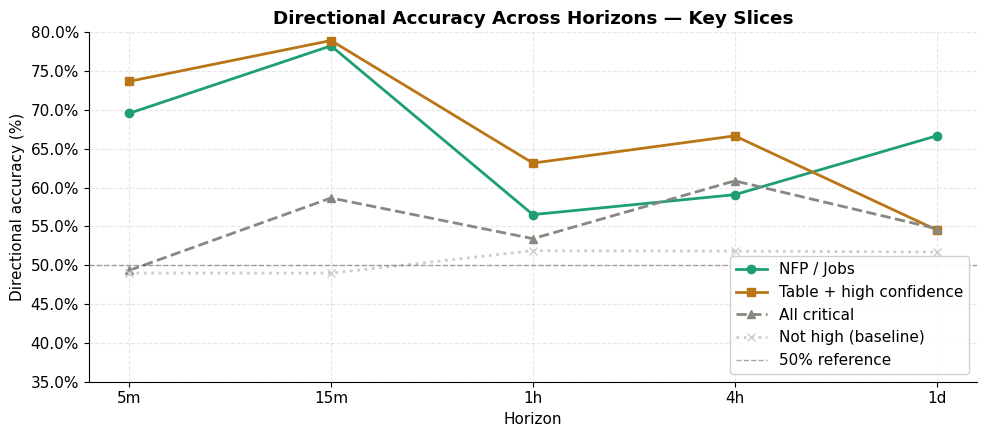

Saved: s2b_direction_by_horizon.png


In [9]:
# ── Direction accuracy across all horizons for key slices ─────────────────
key_slices = {
    'NFP / Jobs':              critical[critical['event_number'].isin([10, 11])],
    'Table + high confidence': critical[(critical['table_used'] == True) &
                                        (critical['direction_confidence'] == 'high')],
    'All critical':            critical,
    'Not high (baseline)':     not_high,
}

fig, ax = plt.subplots(figsize=(10, 4.5))
slice_colors = [TEAL, AMBER, GRAY, '#cccccc']
slice_styles = ['-o', '-s', '--^', ':x']

for (name, grp), color, style in zip(key_slices.items(), slice_colors, slice_styles):
    accs = []
    ns   = []
    for h in HORIZONS:
        acc, n = dir_accuracy(grp, h)
        accs.append(acc * 100 if not np.isnan(acc) else np.nan)
        ns.append(n)
    ax.plot(H_LABELS, accs, style, color=color, label=name, linewidth=2, markersize=6)

ax.axhline(50, color='black', linewidth=1, linestyle='--', alpha=0.35, label='50% reference')
ax.set_ylabel('Directional accuracy (%)')
ax.set_xlabel('Horizon')
ax.set_ylim(35, 80)
ax.yaxis.set_major_formatter(mtick.PercentFormatter())
ax.legend(framealpha=0.9)
ax.set_title('Directional Accuracy Across Horizons — Key Slices', fontweight='bold')
plt.tight_layout()
plt.savefig('s2b_direction_by_horizon.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: s2b_direction_by_horizon.png')

In [10]:
# ── Direction confidence breakdown ────────────────────────────────────────
dir_crit = critical[critical['direction'].isin(['up','down'])].copy()

rows = []
for conf in ['high', 'medium']:
    sub = dir_crit[dir_crit['direction_confidence'] == conf]
    row = {'direction_confidence': conf, 'n': len(sub)}
    for h, hl in zip(['pct_5m','pct_15m','pct_1h'], ['5m','15m','1h']):
        acc, n = dir_accuracy(sub, h)
        row[hl] = f'{acc*100:.1f}%' if n > 0 else 'n/a'
    rows.append(row)

print('Direction accuracy by model confidence level (critical articles only):')
display(pd.DataFrame(rows).set_index('direction_confidence'))
print('\nNote: medium confidence outperforms high confidence at 15m — the model'
      '\nmay be overconfident on events where historical table data is absent.')

Direction accuracy by model confidence level (critical articles only):


,n,5m,15m,1h
direction_confidence,,,,
high,124,53.4%,58.6%,55.2%
medium,34,35.3%,58.8%,46.7%



Note: medium confidence outperforms high confidence at 15m — the model
may be overconfident on events where historical table data is absent.


---
## 3. Monthly Stability

In [11]:
# ── Monthly stats ─────────────────────────────────────────────────────────
import warnings
warnings.filterwarnings('ignore', 'Converting to PeriodArray')

critical['ym'] = critical['dt'].dt.to_period('M')

monthly_rows = []
for ym, grp in critical.groupby('ym'):
    acc15, n15 = dir_accuracy(grp, 'pct_15m')
    acc1h, n1h = dir_accuracy(grp, 'pct_1h')
    monthly_rows.append({
        'month':        str(ym),
        'n critical':   len(grp),
        '15m acc':      round(acc15 * 100, 1) if not np.isnan(acc15) else np.nan,
        '15m n':        n15,
        '1h acc':       round(acc1h * 100, 1) if not np.isnan(acc1h) else np.nan,
        'mean |15m|':   round(grp['pct_15m'].abs().mean() * 100, 4),
    })

monthly_df = pd.DataFrame(monthly_rows)
display(monthly_df.set_index('month'))

,n critical,15m acc,15m n,1h acc,mean |15m|
month,,,,,
2025-08,36,70.6,34,52.9,13.8408
2025-09,24,33.3,24,45.5,8.9994
2025-10,20,60.0,20,77.8,7.5813
2025-11,8,100.0,8,75.0,3.2471
2025-12,8,0.0,8,0.0,3.7964
2026-01,18,62.5,16,12.5,7.8216
2026-02,22,66.7,18,77.8,5.2321
2026-03,24,63.6,22,63.6,2.8533


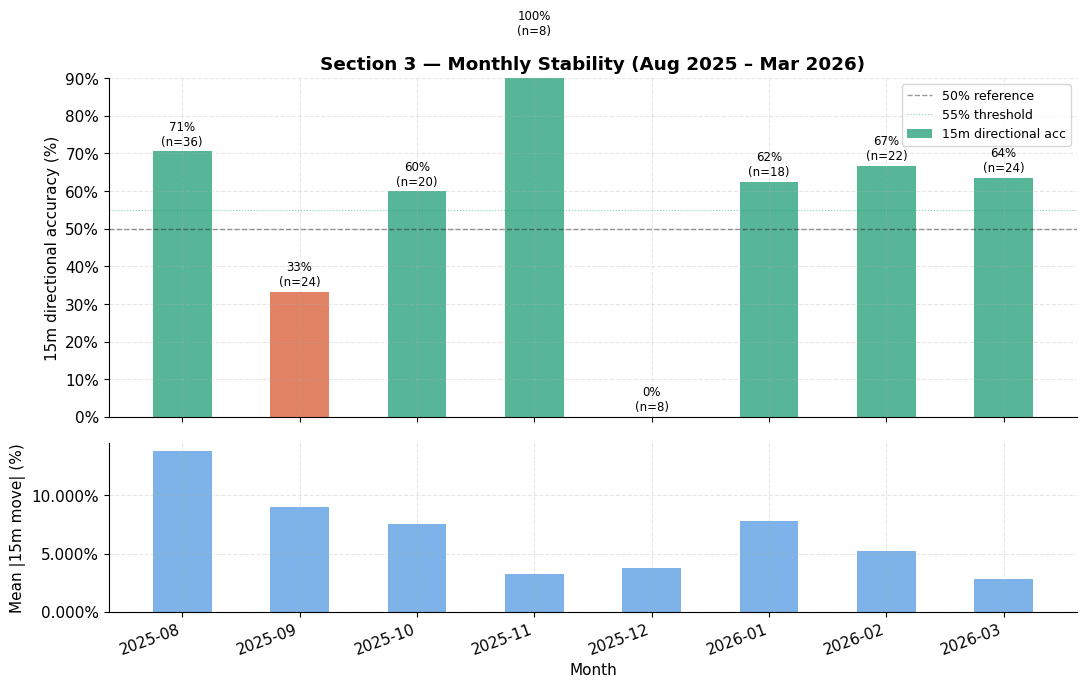

Saved: s3_monthly_stability.png


In [12]:
# ── Chart: monthly accuracy + volume ──────────────────────────────────────
months    = monthly_df['month'].tolist()
acc_vals  = monthly_df['15m acc'].tolist()
n_vals    = monthly_df['n critical'].tolist()
mean_abs  = monthly_df['mean |15m|'].tolist()

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(11, 7), sharex=True,
                                gridspec_kw={'height_ratios': [2, 1]})

# Top: accuracy line
bar_colors = [TEAL if a >= 55 else CORAL if a < 45 else GRAY for a in acc_vals]
ax1.bar(months, acc_vals, color=bar_colors, alpha=0.75, width=0.5, label='15m directional acc')
ax1.axhline(50, color='black', linewidth=1, linestyle='--', alpha=0.4, label='50% reference')
ax1.axhline(55, color=TEAL,   linewidth=0.8, linestyle=':', alpha=0.5, label='55% threshold')

for i, (a, n) in enumerate(zip(acc_vals, n_vals)):
    if not np.isnan(a):
        ax1.text(i, a + 0.8, f'{a:.0f}%\n(n={n})', ha='center', va='bottom', fontsize=8.5)

ax1.set_ylabel('15m directional accuracy (%)')
ax1.set_ylim(0, 90)
ax1.yaxis.set_major_formatter(mtick.PercentFormatter())
ax1.legend(loc='upper right', fontsize=9)
ax1.set_title('Section 3 — Monthly Stability (Aug 2025 – Mar 2026)', fontweight='bold')

# Bottom: mean absolute move
ax2.bar(months, mean_abs, color=BLUE, alpha=0.65, width=0.5)
ax2.set_ylabel('Mean |15m move| (%)')
ax2.set_xlabel('Month')
ax2.yaxis.set_major_formatter(mtick.PercentFormatter(xmax=100, decimals=3))

plt.xticks(rotation=20, ha='right')
plt.tight_layout()
plt.savefig('s3_monthly_stability.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: s3_monthly_stability.png')

---
## 4. SD-Capture: Does High Criticality Find the Biggest Moves?

In [13]:
# ── Moves ≥ 1SD and ≥ 2SD captured ───────────────────────────────────────
def sd_capture(subset, horizon, threshold):
    s = subset[subset['direction'].isin(['up','down']) & subset[horizon].notna()].copy()
    s['actual_dir'] = s[horizon].apply(lambda x: 'up' if x > 0 else 'down')
    above = s[s[horizon].abs() >= threshold]
    hits  = (above['actual_dir'] == above['direction']).sum()
    return hits, len(above)

rows = []
for h, hl in zip(HORIZONS, H_LABELS):
    h1, n1 = sd_capture(critical, h, sd[h])
    h2, n2 = sd_capture(critical, h, sd[h] * 2)
    rows.append({
        'horizon':    hl,
        '1SD thresh': f'{sd[h]*100:.4f}%',
        '≥1SD hits':  f'{h1}/{n1} = {h1/n1*100:.1f}%' if n1 else 'n/a',
        '2SD thresh': f'{sd[h]*2*100:.4f}%',
        '≥2SD hits':  f'{h2}/{n2} = {h2/n2*100:.1f}%' if n2 else 'n/a',
    })

print('SD-capture: directional accuracy on the largest moves\n(among critical articles where |actual move| ≥ 1SD or 2SD):')
display(pd.DataFrame(rows).set_index('horizon'))

SD-capture: directional accuracy on the largest moves
(among critical articles where |actual move| ≥ 1SD or 2SD):


,1SD thresh,≥1SD hits,2SD thresh,≥2SD hits
horizon,,,,
5m,4.2914%,16/30 = 53.3%,8.5829%,8/16 = 50.0%
15m,6.2145%,28/42 = 66.7%,12.4289%,12/18 = 66.7%
1h,11.3750%,26/44 = 59.1%,22.7500%,12/16 = 75.0%
4h,19.9673%,36/50 = 72.0%,39.9346%,14/18 = 77.8%
1d,34.6196%,28/46 = 60.9%,69.2393%,8/12 = 66.7%


In [14]:
# ── What fraction of all ≥1SD moves does the model capture? ───────────────
print('Coverage: what fraction of all ≥1SD moves did "high" criticality flag?\n')
rows = []
for h, hl in zip(HORIZONS, H_LABELS):
    all_big    = df[df[h].abs() >= sd[h]]
    flagged    = critical[critical[h].abs() >= sd[h]]
    coverage   = len(flagged) / len(all_big) if len(all_big) else np.nan
    rows.append({
        'horizon':       hl,
        'all ≥1SD':      len(all_big),
        'flagged high':  len(flagged),
        'coverage':      f'{coverage*100:.1f}%' if not np.isnan(coverage) else 'n/a',
    })
display(pd.DataFrame(rows).set_index('horizon'))

Coverage: what fraction of all ≥1SD moves did "high" criticality flag?



,all ≥1SD,flagged high,coverage
horizon,,,
5m,164,30,18.3%
15m,240,42,17.5%
1h,286,46,16.1%
4h,362,50,13.8%
1d,502,46,9.2%


---
## 5. Summary — What to Take to the Presentation

In [15]:
# ── Headline numbers ──────────────────────────────────────────────────────
vol_lift_15m  = critical['pct_15m'].abs().mean() / not_high['pct_15m'].abs().mean()
_, p_15m      = mannwhitneyu(critical['pct_15m'].dropna().abs(),
                              not_high['pct_15m'].dropna().abs(), alternative='greater')
nfp_acc, nfp_n = dir_accuracy(critical[critical['event_number'].isin([10,11])], 'pct_15m')
best_acc, best_n = dir_accuracy(
    critical[(critical['table_used']==True) & (critical['direction_confidence']=='high')],
    'pct_5m')
overall_acc, overall_n = dir_accuracy(critical, 'pct_15m')

print('═' * 58)
print('  HEADLINE NUMBERS (Aug 2025 – Mar 2026, Apr/May excluded)')
print('═' * 58)
print(f'  Critical articles      : {len(critical)} of {len(relevant)} relevant ({len(critical)/len(relevant)*100:.1f}%)')
print()
print('  VOLATILITY SIGNAL')
print(f'  High criticality lift  : {vol_lift_15m:.2f}× at 15m vs not-high')
print(f'  Mann-Whitney p         : {p_15m:.4f}  (significant: {"yes" if p_15m < 0.05 else "no"})')
print()
print('  DIRECTIONAL ACCURACY AT 15m')
print(f'  All critical           : {overall_acc*100:.1f}%  (n={overall_n})')
print(f'  NFP / Jobs events      : {nfp_acc*100:.1f}%  (n={nfp_n})')
print(f'  Table + high confidence: {best_acc*100:.1f}%  at 5m  (n={best_n})')
print()
print('  BEST MONTH')
best_month = monthly_df.loc[monthly_df['15m acc'].idxmax()]
print(f'  {best_month["month"]}    : {best_month["15m acc"]}%  (n={best_month["n critical"]})')
print('═' * 58)

══════════════════════════════════════════════════════════
  HEADLINE NUMBERS (Aug 2025 – Mar 2026, Apr/May excluded)
══════════════════════════════════════════════════════════
  Critical articles      : 160 of 1538 relevant (10.4%)

  VOLATILITY SIGNAL
  High criticality lift  : 2.49× at 15m vs not-high
  Mann-Whitney p         : 0.0000  (significant: yes)

  DIRECTIONAL ACCURACY AT 15m
  All critical           : 58.7%  (n=150)
  NFP / Jobs events      : 78.3%  (n=46)
  Table + high confidence: 73.7%  at 5m  (n=38)

  BEST MONTH
  2025-11    : 100.0%  (n=8)
══════════════════════════════════════════════════════════


In [16]:
# df = pd.read_csv('data/results_cutoff_v2.csv')

In [17]:
import math

In [18]:
e_calc = [math.e**i for i in [0.5, 1.5, 1.0]]
print(e_calc)
for i in e_calc:
    print(i/sum(e_calc))


[1.6487212707001282, 4.4816890703380645, 2.718281828459045]
0.1863237232258476
0.506480391055654
0.30719588571849843


In [19]:
0.307-1

-0.6930000000000001

In [20]:
import torch
import torch.nn as nn

In [21]:
x = torch.randn(4,5,1)
x

tensor([[[-0.8684],
         [-0.5311],
         [ 0.8736],
         [ 0.7484],
         [ 0.8315]],

        [[-1.6277],
         [-0.7103],
         [ 1.1927],
         [-1.4001],
         [-1.3008]],

        [[-1.0367],
         [ 2.1221],
         [-0.2132],
         [-1.2499],
         [ 0.8602]],

        [[-0.3469],
         [-0.0633],
         [-0.4686],
         [ 3.3586],
         [ 1.6985]]])

In [22]:
key = nn.Linear(1,10,bias=False)

In [23]:
key(x) # 4,5,10

tensor([[[-0.7084, -0.3721, -0.4873,  0.3045,  0.5333,  0.7108,  0.2792,
          -0.1592, -0.2984,  0.8297],
         [-0.4332, -0.2275, -0.2980,  0.1862,  0.3262,  0.4347,  0.1707,
          -0.0974, -0.1825,  0.5074],
         [ 0.7127,  0.3743,  0.4902, -0.3063, -0.5365, -0.7151, -0.2808,
           0.1602,  0.3002, -0.8347],
         [ 0.6105,  0.3206,  0.4200, -0.2624, -0.4596, -0.6126, -0.2406,
           0.1372,  0.2572, -0.7150],
         [ 0.6783,  0.3563,  0.4666, -0.2916, -0.5107, -0.6806, -0.2673,
           0.1525,  0.2857, -0.7945]],

        [[-1.3278, -0.6974, -0.9134,  0.5708,  0.9997,  1.3323,  0.5233,
          -0.2985, -0.5594,  1.5552],
         [-0.5795, -0.3043, -0.3986,  0.2491,  0.4363,  0.5814,  0.2284,
          -0.1303, -0.2441,  0.6787],
         [ 0.9730,  0.5110,  0.6693, -0.4182, -0.7325, -0.9763, -0.3834,
           0.2187,  0.4099, -1.1396],
         [-1.1422, -0.5999, -0.7857,  0.4910,  0.8599,  1.1461,  0.4501,
          -0.2568, -0.4812,  1.3377],